In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !rm -rf /content/drive/MyDrive/SNTBackgroundChangerProject

In [ ]:
import os, sys, glob, math, random, time
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image

In [ ]:
import os
import requests
from tqdm import tqdm

def download_big_file(dest_path,url):
    # Ensure destination directory exists
    os.makedirs(os.path.dirname(dest_path), exist_ok=True)

    if os.path.exists(dest_path):
        print(f"✅ Skipping {os.path.basename(dest_path)} (already exists)")
        return

    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))

    with open(dest_path, 'wb') as file, tqdm(
        desc=os.path.basename(dest_path),
        total=total,
        unit='B',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(chunk_size=1024):
            size = file.write(data)
            bar.update(size)

In [ ]:
import os
import zipfile
from tqdm import tqdm


def unzip_folder(zip_path, extract_to, sub_dir="train"):
    expected_path = os.path.join(extract_to, sub_dir)
    if os.path.exists(expected_path) and any(os.scandir(expected_path)):
        print(f"⚠️ Skipping extraction: {expected_path} already populated")
        return

    print(f"📦 Extracting {os.path.basename(zip_path)} → {extract_to}")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for member in tqdm(zip_ref.infolist(), desc="Extracting", unit="file"):
            zip_ref.extract(member, extract_to)

In [ ]:
# zip_path = "/content/drive/MyDrive/SNTBackgroundChangerProject/raw_zips/AIM-500.zip"
# extract_path = "/content/drive/MyDrive/SNTBackgroundChangerProject"
# unzip_folder(zip_path, extract_path)

📦 Extracting AIM-500.zip → /content/drive/MyDrive/SNTBackgroundChangerProject


Extracting: 100%|██████████| 2003/2003 [00:46<00:00, 43.51file/s]


In [ ]:
# zip_path = "/content/drive/MyDrive/SNTBackgroundChangerProject/raw_zips/AIT_Faculty.zip"
# extract_path = "/content/drive/MyDrive/SNTBackgroundChangerProject"
# unzip_folder(zip_path, extract_path)

📦 Extracting AIT_Faculty.zip → /content/drive/MyDrive/SNTBackgroundChangerProject


Extracting: 100%|██████████| 249/249 [00:03<00:00, 71.91file/s] 


In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.maxpool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.maxpool(c1)

        c2 = self.down2(p1)
        p2 = self.maxpool(c2)

        c3 = self.down3(p2)
        p3 = self.maxpool(c3)

        c4 = self.down4(p3)
        p4 = self.maxpool(c4)

        bn = self.bottleneck(p4)

        u4 = self.up4(bn)
        merge4 = torch.cat([u4, c4], dim=1)
        c5 = self.conv4(merge4)

        u3 = self.up3(c5)
        merge3 = torch.cat([u3, c3], dim=1)
        c6 = self.conv3(merge3)

        u2 = self.up2(c6)
        merge2 = torch.cat([u2, c2], dim=1)
        c7 = self.conv2(merge2)

        u1 = self.up1(c7)
        merge1 = torch.cat([u1, c1], dim=1)
        c8 = self.conv1(merge1)

        out = self.final(c8)
        return torch.sigmoid(out)


In [ ]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0

    for imgs, masks in tqdm(loader, desc="Training"):
        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Validation"):
            imgs = imgs.to(device)
            masks = masks.to(device)

            preds = model(imgs)
            loss = criterion(preds, masks)

            running_loss += loss.item()

    return running_loss / len(loader)


In [ ]:
import matplotlib.pyplot as plt

def infer_show(model, img_path, transform):
    model.eval()
    img = Image.open(img_path).convert("RGB")

    t = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(t)[0][0].cpu().numpy()

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.title("Input Image")
    plt.imshow(img)

    plt.subplot(1,2,2)
    plt.title("Predicted Matte")
    plt.imshow(pred, cmap="gray")

    plt.show()


In [ ]:
train_img_dir = "/content/dataset/train/image"
train_mask_dir = "/content/dataset/train/mask"

val_img_dir = "/content/dataset/val/image"
val_mask_dir = "/content/dataset/val/mask"


In [ ]:
from pathlib import Path
import shutil
import random

# Define source dataset roots
AIM_ROOT = Path('/content/drive/MyDrive/SNTBackgroundChangerProject/AIM-500')
AIT_ROOT = Path('/content/drive/MyDrive/SNTBackgroundChangerProject/AIT_Faculty')

# Define destination root
DATA_ROOT = Path('/content/drive/MyDrive/SNTBackgroundChangerProject/mydata')

# Define split structure
splits = ['train', 'val', 'test']
subdirs = ['images', 'mattes']

# Create destination directories
for split in splits:
    for subdir in subdirs:
        (DATA_ROOT / split / subdir).mkdir(parents=True, exist_ok=True)

In [ ]:
train_img_dir = DATA_ROOT / 'train' / 'images'
train_matte_dir = DATA_ROOT / 'train' / 'mattes'
val_img_dir = DATA_ROOT / 'val' / 'images'
val_matte_dir = DATA_ROOT / 'val' / 'mattes'
test_img_dir = DATA_ROOT / 'test' / 'images'
test_matte_dir = DATA_ROOT / 'test' / 'mattes'

In [ ]:
from pathlib import Path
import os

def collect_pairs(original_dir: Path, mask_dir: Path, auto_rename=True):
    """
    Collect matching image–matte pairs even if:
      • File extensions differ (.jpg, .png, etc.)
      • Matte filenames include '_matte' suffix
    Optionally auto-renames mattes to match their images.
    Returns: list of (image_path, matte_path) tuples
    """
    original_files = list(original_dir.glob('*'))
    mask_files = list(mask_dir.glob('*'))

    # Build map of matte stems (handle '_matte' suffix)
    mask_map = {}
    for f in mask_files:
        stem = f.stem
        if stem.endswith('_matte'):
            stem = stem[:-6]  # remove suffix
        mask_map[stem] = f

    pairs = []
    renamed = 0
    for img_path in original_files:
        stem = img_path.stem

        # Direct match
        if stem in mask_map:
            matte_path = mask_map[stem]

            # Rename matte if name contains "_matte"
            if auto_rename and "_matte" in matte_path.stem:
                new_name = stem + matte_path.suffix
                new_path = matte_path.with_name(new_name)
                if not new_path.exists():
                    os.rename(matte_path, new_path)
                    matte_path = new_path
                    renamed += 1
                    print(f"✅ Renamed: {matte_path.name}")
                else:
                    print(f"⚠️ Skipped rename (exists): {new_name}")

            pairs.append((img_path, matte_path))

        else:
            # Try fuzzy match (partial overlap)
            match = next((m for k, m in mask_map.items() if stem in k or k in stem), None)
            if match:
                pairs.append((img_path, match))
            else:
                print(f"⚠️ No matching matte found for: {img_path.name}")

    print(f"\n✅ Collected {len(pairs)} valid pairs | 🔄 Renamed: {renamed}")
    return pairs

In [ ]:
from tqdm import tqdm
import shutil

def copy_split(pairs, split, dest_root):
    progress = tqdm(pairs, desc="Copying images", unit="file")
    for i, (img_path, mask_path) in enumerate(progress, 1):
        dest_img = dest_root / split / 'images' / img_path.name
        dest_mask = dest_root / split / 'mattes' / mask_path.name

        if not dest_img.exists() and not dest_mask.exists():
            progress.set_description(f"{i} copying {img_path.name}")
            shutil.copy(img_path, dest_img)
            shutil.copy(mask_path, dest_mask)

In [ ]:
def split_and_copy(original_dir, mask_dir, split_ratios, dest_root):
    pairs = collect_pairs(original_dir, mask_dir)
    print(f"Found {len(pairs)} pairs in {original_dir}")

    random.shuffle(pairs)
    total = len(pairs)
    train_end = int(split_ratios[0] * total)
    val_end = train_end + int(split_ratios[1] * total)

    splits_map = {
        'train': pairs[:train_end],
        'val': pairs[train_end:val_end],
        'test': pairs[val_end:]
    }

    for split, items in splits_map.items():
        copy_split(items, split, dest_root)

In [ ]:
print("AIM images:", len(list(Path(AIM_ROOT/'original').glob('*'))))
print("AIM mattes:", len(list(Path(AIM_ROOT / 'mask').glob('*'))))
print("AIT images:", len(list(Path(AIT_ROOT / 'Images').glob('*'))))
print("AIT mattes:", len(list(Path(AIT_ROOT / 'Mattes').glob('*'))))

AIM images: 500
AIM mattes: 500
AIT images: 114
AIT mattes: 132


In [ ]:
split_ratios = [0.7, 0.15, 0.15]  # train, val, test


In [ ]:
# !rm -rf DATA_ROOT

In [ ]:
split_and_copy(AIM_ROOT / 'original', AIM_ROOT / 'mask', split_ratios, DATA_ROOT)


✅ Collected 500 valid pairs | 🔄 Renamed: 0
Found 500 pairs in /content/drive/MyDrive/SNTBackgroundChangerProject/AIM-500/original


75 copying o_659c5db8.jpg: 100%|██████████| 75/75 [00:55<00:00,  1.36file/s]


In [ ]:
split_and_copy(AIT_ROOT / 'Images', AIT_ROOT / 'Mattes', split_ratios, DATA_ROOT)

✅ Renamed: Andrew20Macintosh_edited.png
✅ Renamed: Attaphongse Taparugssanage.png
✅ Renamed: Dr. Amararatne Yakupitiyage.png
✅ Renamed: Dr. Arlene Lu-Gonzales.png
✅ Renamed: Dr. Avirut Puttiwongrak.png
✅ Renamed: Dr. Ayushman Bhatt.png
✅ Renamed: Dr. Branesh Madhavan.png
✅ Renamed: Dr. Chaklam Silpasuwanchai.png
✅ Renamed: Dr. Chutiporn Anutariya.png
✅ Renamed: Dr. Djoen San Santoso.png
✅ Renamed: Dr. Ekbordin Winijkul.png
✅ Renamed: Dr. Farhad Zulfiqar.png
✅ Renamed: Dr. Gerard Tocquer.png
✅ Renamed: Dr. Ha Thanh Dong.png
✅ Renamed: Dr. Hayat Ullah.png
✅ Renamed: Dr. Indrajit Pal.png
✅ Renamed: Dr. Jitti Mungkalasiri.png
✅ Renamed: Dr. Joyee S. Chatterjee.png
✅ Renamed: Dr. Julaikha Bente Hossain.png
✅ Renamed: Dr. Khin Myat Kyaw.png
✅ Renamed: Dr. Kittipong Kkkachai.png
✅ Renamed: Dr. Krishna R. Salin.png
✅ Renamed: Dr. Kuo-Chieh Chao.png
✅ Renamed: Dr. Lakeesha K. Ransom.png
✅ Renamed: Dr. Lonn Pichdara.png
✅ Renamed: Dr. Mohana Sundaram Shanmugam.png
✅ Renamed: Dr. Muhammad Junai.p

18 copying Mr. Kevin Pereira.jpg: 100%|██████████| 18/18 [00:00<00:00, 41.85file/s]


In [ ]:
from PIL import Image, UnidentifiedImageError
from pathlib import Path
import os

def remove_unidentified(folder_path):
    folder = Path(folder_path)
    removed = []

    for file in folder.glob("*"):
        try:
            Image.open(file).verify()
        except UnidentifiedImageError:
            print(f"❌ Removing unreadable file: {file.name}")
            os.remove(file)
            removed.append(file.stem)  # store stem for cross-checking

    print(f"✅ Removed {len(removed)} files from {folder.name}")
    return removed

# Define your paths
# img_dir = "/content/drive/MyDrive/modnet_data/train/images"
# matte_dir = "/content/drive/MyDrive/modnet_data/train/mattes"

# Remove unreadable files
bad_img_stems = remove_unidentified(train_img_dir)
bad_matte_stems = remove_unidentified(train_matte_dir)

# Optional: remove mismatched pairs
def remove_mismatched_pairs(img_dir, matte_dir, bad_stems):
    for stem in bad_stems:
        img_file = list(Path(img_dir).glob(stem + ".*"))
        matte_file = list(Path(matte_dir).glob(stem + ".*"))
        for f in img_file + matte_file:
            if f.exists():
                print(f"🧹 Removing mismatched file: {f.name}")
                os.remove(f)

# Remove any remaining mismatched pairs
remove_mismatched_pairs(train_img_dir, train_matte_dir, set(bad_img_stems + bad_matte_stems))


✅ Removed 0 files from images
✅ Removed 0 files from mattes


In [ ]:
print("Number of train image files:", len(list(train_img_dir.glob('*'))))
print("Number of train matte files:", len(list(train_matte_dir.glob('*'))))
print("Number of val image files:", len(list(val_img_dir.glob('*'))))
print("Number of val matte files:", len(list(val_matte_dir.glob('*'))))

Number of train image files: 430
Number of train matte files: 429
Number of val image files: 91
Number of val matte files: 91


In [ ]:
from PIL import Image, UnidentifiedImageError
from pathlib import Path
import os

def remove_unidentified(folder_path):
    folder = Path(folder_path)
    removed = []

    for file in folder.glob("*"):
        try:
            Image.open(file).verify()
        except UnidentifiedImageError:
            print(f"❌ Removing unreadable file: {file.name}")
            os.remove(file)
            removed.append(file.stem)  # store stem for cross-checking

    print(f"✅ Removed {len(removed)} files from {folder.name}")
    return removed

# Define your paths
# img_dir = "/content/drive/MyDrive/modnet_data/train/images"
# matte_dir = "/content/drive/MyDrive/modnet_data/train/mattes"

# Remove unreadable files
bad_img_stems = remove_unidentified(train_img_dir)
bad_matte_stems = remove_unidentified(train_matte_dir)

# Optional: remove mismatched pairs
def remove_mismatched_pairs(img_dir, matte_dir, bad_stems):
    for stem in bad_stems:
        img_file = list(Path(img_dir).glob(stem + ".*"))
        matte_file = list(Path(matte_dir).glob(stem + ".*"))
        for f in img_file + matte_file:
            if f.exists():
                print(f"🧹 Removing mismatched file: {f.name}")
                os.remove(f)

remove_mismatched_pairs(train_img_dir, train_matte_dir, set(bad_img_stems + bad_matte_stems))

✅ Removed 0 files from images
✅ Removed 0 files from mattes


In [ ]:
class PortraitDataset(Dataset):
    def __init__(self, img_dir, matte_dir, img_transform=None, matte_transform=None):
        self.img_dir = Path(img_dir)
        self.matte_dir = Path(matte_dir)
        self.img_transform = img_transform
        self.matte_transform = matte_transform

        img_stems = {p.stem for p in self.img_dir.glob('*')}
        matte_stems = {p.stem for p in self.matte_dir.glob('*')}
        self.common_stems = sorted(list(img_stems & matte_stems))
        print(f"✅ Found {len(self.common_stems)} paired samples in {self.img_dir.parent.name}")

    def __len__(self):
        return len(self.common_stems)

    def __getitem__(self, idx):
          stem = self.common_stems[idx]

          img_matches = list(self.img_dir.glob(stem + '.*'))
          matte_matches = list(self.matte_dir.glob(stem + '.*'))

          if not img_matches or not matte_matches:
              print(f"⚠️ Missing file for stem: {stem}")
              return self.__getitem__((idx + 1) % len(self.common_stems))  # fallback to next sample

          img_path = img_matches[0]
          matte_path = matte_matches[0]

          try:
              image = Image.open(img_path).convert("RGB")
              matte = Image.open(matte_path).convert("L")
          except UnidentifiedImageError:
              print(f"❌ Unreadable image or matte: {stem}")
              return self.__getitem__((idx + 1) % len(self.common_stems))

          if self.img_transform:
              image = self.img_transform(image)
          if self.matte_transform:
              matte = self.matte_transform(matte)

          return image, matte

In [ ]:
import torchvision.models as models

class UNetResNet34(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None)

        # Encoder
        self.enc1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.enc2 = nn.Sequential(resnet.layer1)
        self.enc3 = nn.Sequential(resnet.layer2)
        self.enc4 = nn.Sequential(resnet.layer3)
        self.enc5 = nn.Sequential(resnet.layer4)

        # Decoder
        self.up4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec4 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = DoubleConv(32, 32)

        self.out_conv = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        d4 = self.up4(e5)
        d4 = self.dec4(torch.cat([d4, e4], 1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], 1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], 1))

        d1 = self.up1(d2)
        d1 = self.dec1(d1)

        out = self.out_conv(d1)
        return torch.sigmoid(out)


In [ ]:
import torchvision.transforms as T

transform_img = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor()
])

transform_matte = T.Compose([
    T.Resize((512, 512)),
    T.ToTensor()
])

In [ ]:
# transform_img = transforms.Compose([
#     transforms.Resize((768, 768)),
#     transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(10),
#     transforms.ToTensor(),
#     transforms.Normalize([0.5]*3, [0.5]*3),
# ])



In [ ]:
# transform_matte = transforms.Compose([
#     transforms.Resize((768, 768)),
#     transforms.ToTensor(),   # converts 0–255 → 0–1
# ])


In [ ]:
from torch.utils.data import DataLoader
from torchvision import transforms

# --- Image preprocessing ---
# Resize all samples to 512×512 (MODNet input size) and convert to tensors
# Normalization is optional here; MODNet uses range [-1, 1] internally.
transform_train = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

transform_val = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# --- Create Dataset instances ---
train_ds = PortraitDataset(
    train_img_dir,
    train_matte_dir,
    img_transform=transform_train,
    # matte_transform=transform_matte_train  # optional
    matte_transform=transform_matte
)

val_ds = PortraitDataset(
    val_img_dir,
    val_matte_dir,
    img_transform=transform_val,
    # matte_transform=transform_matte_val  # optional
    matte_transform=transform_matte
)

# --- DataLoaders ---
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=0, pin_memory=True)


✅ Found 429 paired samples in train
✅ Found 91 paired samples in val


In [ ]:
from skimage.metrics import structural_similarity as ssim
import numpy as np
import torch

def metric_ssim(pred, target):
    """
    pred, target: PyTorch tensors in range [0,1], shape [1,H,W] or [H,W]
    returns float
    """
    pred_np = pred.squeeze().detach().cpu().numpy()
    target_np = target.squeeze().detach().cpu().numpy()

    pred_np = np.clip(pred_np, 0, 1)
    target_np = np.clip(target_np, 0, 1)

    return ssim(pred_np, target_np, data_range=1.0)


In [ ]:
def metric_mae(pred, target):
    """
    pred, target: tensors in [0,1]
    """
    return torch.abs(pred - target).mean().item()


In [ ]:
def metric_iou(pred, target, threshold=0.5):
    """
    pred, target: tensors in [0,1]
    """
    pred_bin = (pred > threshold).float()
    target_bin = (target > threshold).float()

    intersection = (pred_bin * target_bin).sum()
    union = pred_bin.sum() + target_bin.sum() - intersection

    if union == 0:
        return 1.0
    return (intersection / union).item()


In [ ]:
def compute_metrics(model, dataloader, device):
    model.eval()
    total_ssim = 0.0
    total_mae  = 0.0
    total_iou  = 0.0
    count = 0

    with torch.no_grad():
        for imgs, mattes in dataloader:
            imgs = imgs.to(device)
            mattes = mattes.to(device)

            preds = model(imgs)

            for b in range(preds.size(0)):
                pred_b = preds[b]
                matte_b = mattes[b]

                total_ssim += metric_ssim(pred_b, matte_b)
                total_mae  += metric_mae(pred_b, matte_b)
                total_iou  += metric_iou(pred_b, matte_b)

                count += 1

    return (
        total_ssim / count,
        total_mae / count,
        total_iou / count
    )



In [ ]:
# def dice_loss(pred, target, smooth=1):
#     pred = pred.contiguous()
#     target = target.contiguous()

#     intersection = (pred * target).sum()
#     d = (2.*intersection + smooth)/(pred.sum() + target.sum() + smooth)
#     return 1 - d




In [ ]:
# criterion = lambda p, t: 0.5*nn.BCELoss()(p,t) + 0.5*dice_loss(p,t)

In [ ]:
class MatteLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()

    def dice_loss(self, pred, gt):
        smooth = 1
        num = 2 * (pred * gt).sum()
        den = pred.sum() + gt.sum() + smooth
        return 1 - num / den

    def laplacian_loss(self, pred, gt):
        lap = nn.L1Loss()
        lap_filter = torch.tensor([[0,1,0],[1,-4,1],[0,1,0]], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        lap_filter = lap_filter.to(pred.device)
        pred_l = torch.nn.functional.conv2d(pred, lap_filter, padding=1)
        gt_l = torch.nn.functional.conv2d(gt, lap_filter, padding=1)
        return lap(pred_l, gt_l)

    def forward(self, pred, gt):
        return (
            self.bce(pred, gt) +
            0.5 * self.dice_loss(pred, gt) +
            0.1 * self.laplacian_loss(pred, gt)
        )


In [ ]:
criterion = MatteLoss()


In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = UNet().to(device)
# criterion = nn.BCELoss()
model=UNetResNet34(pretrained=True).to(device)
# criterion = MatteLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)



In [ ]:

EPOCHS = 30
train_losses = []
val_losses = []
ssim_scores = []
mae_scores = []
iou_scores = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    val_loss = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.4f}  |  Val Loss: {val_loss:.4f}")

    ssim_val, mae_val, iou_val = compute_metrics(model, val_loader, device)
    ssim_scores.append(ssim_val)
    mae_scores.append(mae_val)
    iou_scores.append(iou_val)

    if ssim_val is not None:
        print(f"📈 SSIM: {ssim_val:.4f} | MAE: {mae_val:.4f} | IoU: {iou_val:.4f}")
    else:
        print("📈 SSIM, MAE, IoU: Skipped due to empty validation batch.")


Epoch 1/30


Training:   0%|          | 0/108 [00:00<?, ?it/s]

Validation:   0%|          | 0/46 [00:00<?, ?it/s]

Train Loss: 0.4071  |  Val Loss: 0.3543
📈 SSIM: 0.2361 | MAE: 0.2569 | IoU: 0.7369

Epoch 2/30


Training:   0%|          | 0/108 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/46 [00:00<?, ?it/s]

Train Loss: 0.0469  |  Val Loss: 0.1039
📈 SSIM: 0.5430 | MAE: 0.0441 | IoU: 0.9045

Epoch 30/30


Training:   0%|          | 0/108 [00:00<?, ?it/s]

Validation:   0%|          | 0/46 [00:00<?, ?it/s]

Train Loss: 0.0449  |  Val Loss: 0.0983
📈 SSIM: 0.6722 | MAE: 0.0414 | IoU: 0.9066


In [ ]:
import matplotlib.pyplot as plt

def plot_metric(metric_values, title, ylabel, color="blue"):
    epochs = range(1, len(metric_values) + 1)
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, metric_values, label=title, color=color)
    plt.title(f"{title} over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

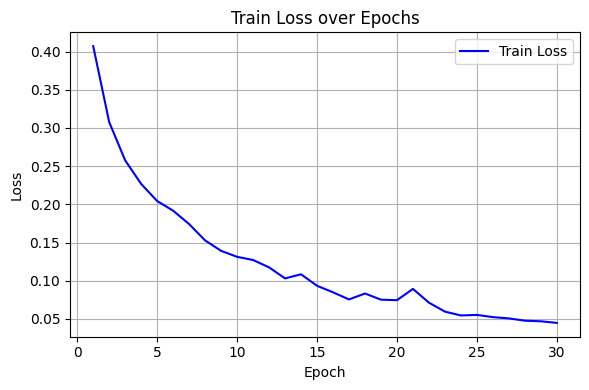

In [ ]:
plot_metric(train_losses, "Train Loss", "Loss", "blue")

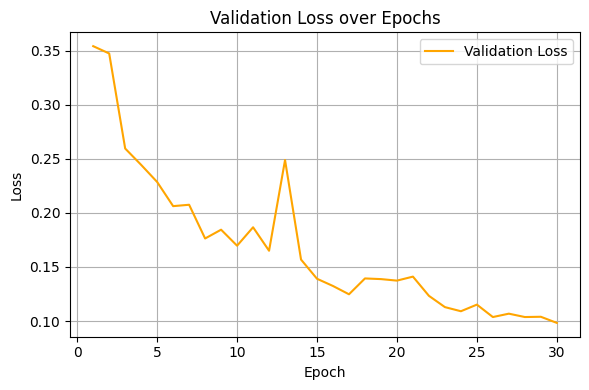

In [ ]:
plot_metric(val_losses, "Validation Loss", "Loss", "orange")

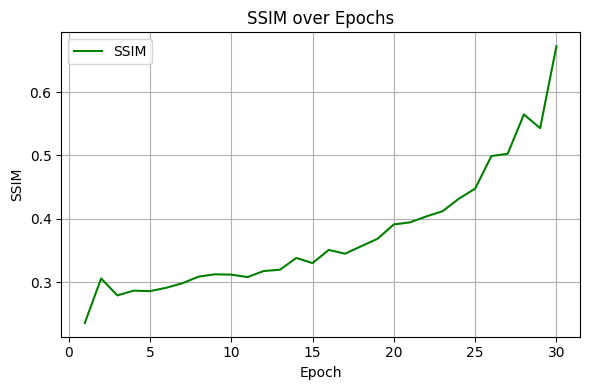

In [ ]:
plot_metric(ssim_scores, "SSIM", "SSIM", "green")

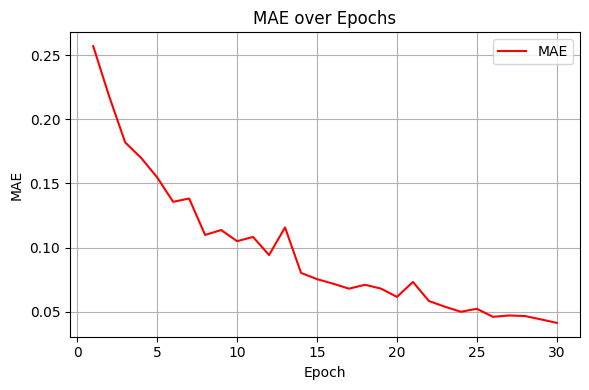

In [ ]:
plot_metric(mae_scores, "MAE", "MAE", "red")

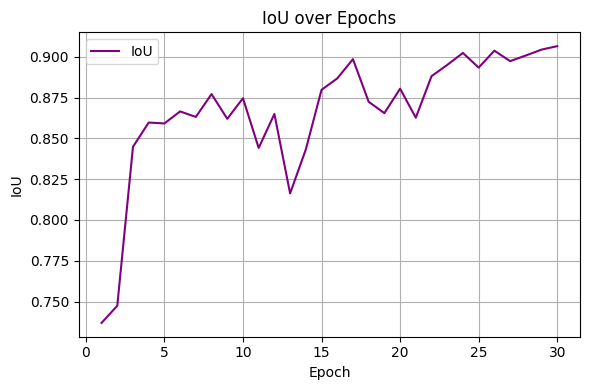

In [ ]:
plot_metric(iou_scores, "IoU", "IoU", "purple")

In [ ]:
SAVE_DIR = Path('/content/drive/MyDrive/SNTBackgroundChangerProject/unet_data/output_models')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = SAVE_DIR / 'unet_model.pt'
torch.save(model.state_dict(), MODEL_PATH)
print(f"✅ Model saved to: {MODEL_PATH}")

✅ Model saved to: /content/drive/MyDrive/SNTBackgroundChangerProject/unet_data/output_models/unet_model.pt


In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import numpy as np

# Automatically match training preprocessing
def auto_preprocess(img):
    auto_transform = transforms.Compose([
        transforms.Resize((512, 512)),             # match your training size
        transforms.ToTensor(),                     # convert to tensor
        transforms.Normalize([0.5]*3, [0.5]*3)     # match training normalization
    ])
    return auto_transform(img)


In [ ]:
def predict_test_images(model, test_img_dir, device,
                        num_samples=6, cols=3):
    """
    Predict and visualize test images with auto-preprocessing
    """
    model.eval()

    img_list = sorted([
        f for f in os.listdir(test_img_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    num_samples = min(num_samples, len(img_list))
    rows = int(np.ceil(num_samples / cols))

    plt.figure(figsize=(15, rows * 5))

    for i in range(num_samples):
        img_name = img_list[i]
        img_path = os.path.join(test_img_dir, img_name)

        # Load image
        img = Image.open(img_path).convert("RGB")

        # Auto transform
        img_t = auto_preprocess(img).unsqueeze(0).to(device)

        # Inference
        with torch.no_grad():
            pred = model(img_t)[0][0].cpu().numpy()

        # Plot input
        plt.subplot(rows, cols * 2, i * 2 + 1)
        plt.imshow(img)
        plt.title(f"Input: {img_name}")
        plt.axis("off")

        # Plot prediction
        plt.subplot(rows, cols * 2, i * 2 + 2)
        plt.imshow(pred, cmap="gray")
        plt.title("Predicted Matte")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


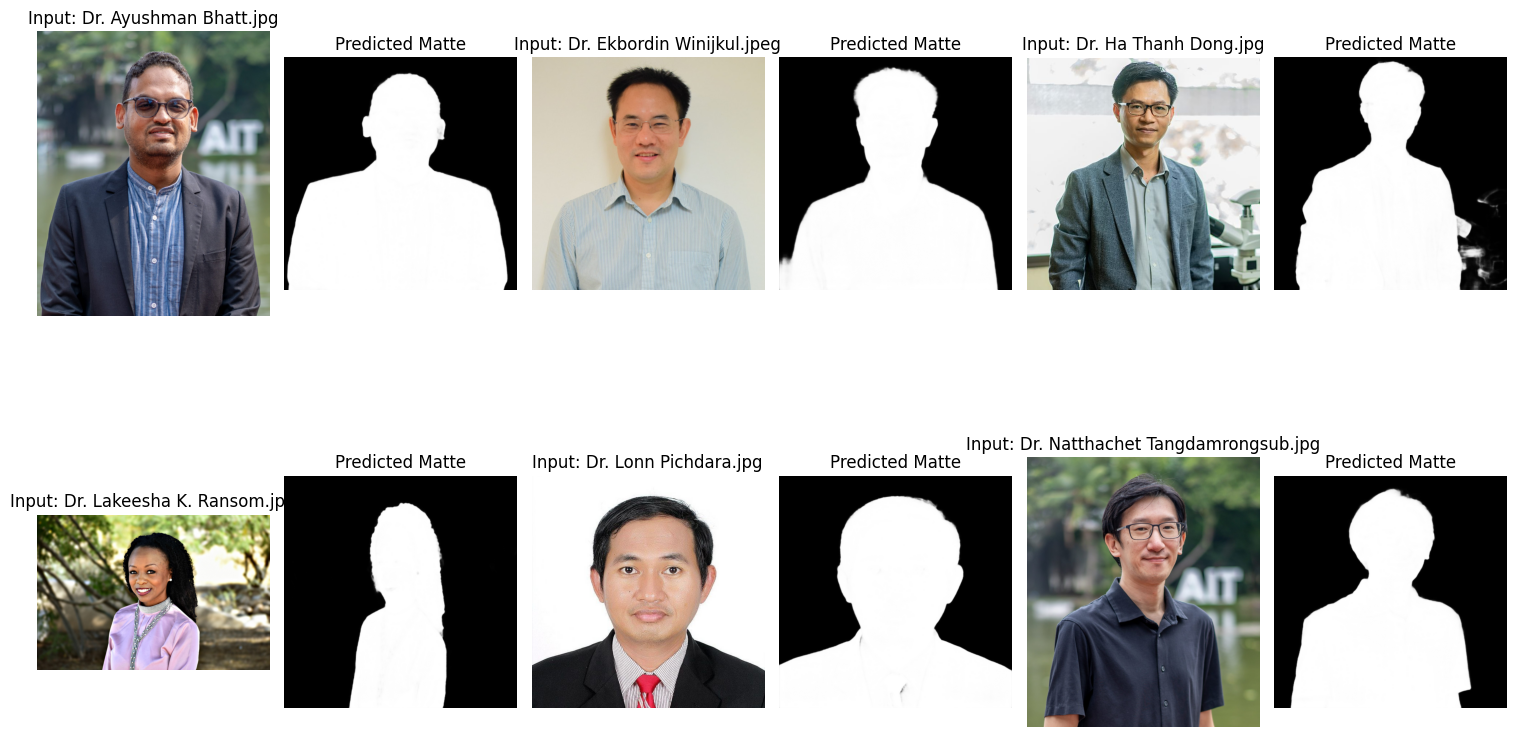

In [ ]:
# test_img_dir = "./data/test/image"

predict_test_images(
    model=model,
    test_img_dir=test_img_dir,
    device=device,
    num_samples=6,
    cols=3
)



In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_one_image(model, img_path, device="cuda"):
    """
    Predict matte for a single image using U-Net.
    Auto-resize, auto-normalize, no need for external transforms.
    """

    # Load and preprocess
    img = Image.open(img_path).convert("RGB")

    preprocess = transforms.Compose([
        transforms.Resize((512, 512)),          # match training size
        transforms.ToTensor(),                  # convert to tensor (0-1)
        transforms.Normalize([0.5]*3, [0.5]*3)  # normalize same as training
    ])

    img_t = preprocess(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        pred = model(img_t)[0][0].cpu().numpy()

    return img, pred


In [ ]:
def show_one_prediction(img, pred):
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(pred, cmap="gray")
    plt.title("Predicted Matte")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


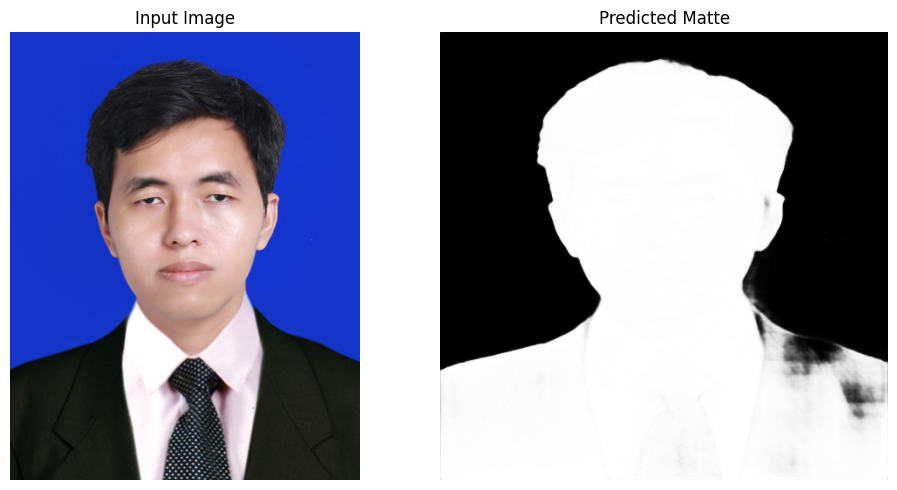

In [ ]:
img_path = "/content/Sat Naing Tun.jpg"

img, pred = predict_one_image(model, img_path, device)
show_one_prediction(img, pred)
